# Clustering and PCA

### Mushroom Dataset

Podeis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay muchas variables, todas ellas categóricas, por lo que exploraciones con scatterplot no nos serán útiles como en otros casos.

La variable a predecir ``poisonous`` es binaria.


In [1]:
# Carga de librerías, las que hemos considerado básicas, añadid lo que queráis :)

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Download latest version
path = 'https://raw.githubusercontent.com/juancmacias/datas/main/DataSet/mushrooms.csv'
df = pd.read_csv(path)

### Leer conjunto de datos y primer vistazo

In [2]:
# Leer el csv y sacar por pantalla las cinco primeras filas.
print(df.head(5))

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

### Exploración de datos

In [3]:
# Descripción del conjunto de datos, estándard.
descripcion = {
    "Número de instancias": df.shape[0],
    "Número de características": df.shape[1] - 1,  # Excluyendo la variable objetivo 'class'
    "Valores únicos por variable": df.nunique().to_dict(),
    "Valores nulos": df.isnull().sum().to_dict()
}

descripcion

{'Número de instancias': 8124,
 'Número de características': 22,
 'Valores únicos por variable': {'class': 2,
  'cap-shape': 6,
  'cap-surface': 4,
  'cap-color': 10,
  'bruises': 2,
  'odor': 9,
  'gill-attachment': 2,
  'gill-spacing': 2,
  'gill-size': 2,
  'gill-color': 12,
  'stalk-shape': 2,
  'stalk-root': 5,
  'stalk-surface-above-ring': 4,
  'stalk-surface-below-ring': 4,
  'stalk-color-above-ring': 9,
  'stalk-color-below-ring': 9,
  'veil-type': 1,
  'veil-color': 4,
  'ring-number': 3,
  'ring-type': 5,
  'spore-print-color': 9,
  'population': 6,
  'habitat': 7},
 'Valores nulos': {'class': 0,
  'cap-shape': 0,
  'cap-surface': 0,
  'cap-color': 0,
  'bruises': 0,
  'odor': 0,
  'gill-attachment': 0,
  'gill-spacing': 0,
  'gill-size': 0,
  'gill-color': 0,
  'stalk-shape': 0,
  'stalk-root': 0,
  'stalk-surface-above-ring': 0,
  'stalk-surface-below-ring': 0,
  'stalk-color-above-ring': 0,
  'stalk-color-below-ring': 0,
  'veil-type': 0,
  'veil-color': 0,
  'ring-number'

In [4]:
# Información sobre el tipo de datos de cada feature.
pd.DataFrame({
    'Feature': df.columns,
    'Unique values': [df[col].unique() for col in df.columns]
})

,Feature,Unique values
0,class,"[p, e]"
1,cap-shape,"[x, b, s, f, k, c]"
2,cap-surface,"[s, y, f, g]"
3,cap-color,"[n, y, w, g, e, p, b, u, c, r]"
4,bruises,"[t, f]"
5,odor,"[p, a, l, n, f, c, y, s, m]"
6,gill-attachment,"[f, a]"
7,gill-spacing,"[c, w]"
8,gill-size,"[n, b]"
9,gill-color,"[k, n, g, p, w, h, u, e, b, r, y, o]"


#### Calcular el número de nulos de cada feature

In [5]:
# Igual que otras veces, una linea, contar los nulos por variable.
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [6]:
# Obtener un nuevo dataframe de dos columnas donde en la primera estén las features (features) y en la otra los valores únicos
# asociados (n_values).
unique_vals_df = pd.DataFrame({
    'Feature': df.columns,
    'n_values': [sorted(df[col].dropna().unique()) for col in df.columns]
})

print(unique_vals_df)

                     Feature                              n_values
0                      class                                [e, p]
1                  cap-shape                    [b, c, f, k, s, x]
2                cap-surface                          [f, g, s, y]
3                  cap-color        [b, c, e, g, n, p, r, u, w, y]
4                    bruises                                [f, t]
5                       odor           [a, c, f, l, m, n, p, s, y]
6            gill-attachment                                [a, f]
7               gill-spacing                                [c, w]
8                  gill-size                                [b, n]
9                 gill-color  [b, e, g, h, k, n, o, p, r, u, w, y]
10               stalk-shape                                [e, t]
11                stalk-root                       [?, b, c, e, r]
12  stalk-surface-above-ring                          [f, k, s, y]
13  stalk-surface-below-ring                          [f, k, s

#### Tratar aquellos valores que entendamos que sean nulos


In [7]:
# Imputaciones. Podéis quitar esos puntos (fila entera), imputar con la moda o dejar ese valor como una posibilidad más.
df['stalk-root'].value_counts()

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64

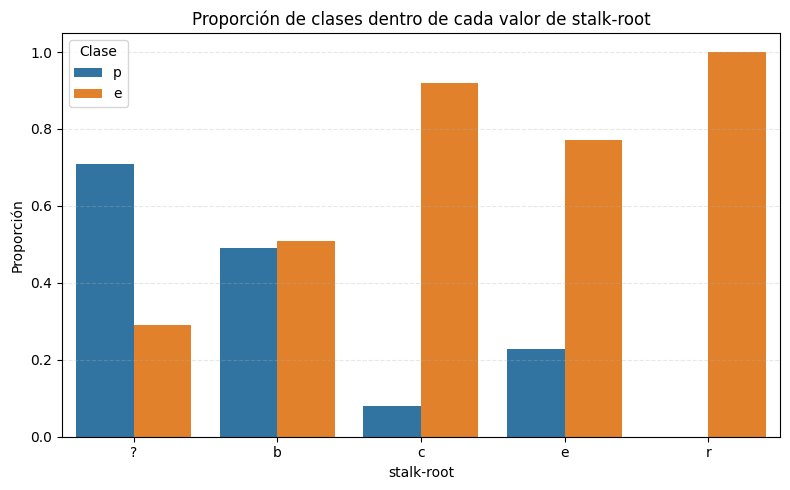

In [8]:
# Creamos proporciones de clases dentro de cada valor de stalk-root
proportions = (
    df.groupby('stalk-root')['class']
    .value_counts(normalize=True)
    .rename('proporcion')
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=proportions,
    x='stalk-root',
    y='proporcion',
    hue='class',
    order=sorted(df['stalk-root'].unique())
)

plt.title("Proporción de clases dentro de cada valor de stalk-root")
plt.ylabel("Proporción")
plt.xlabel("stalk-root")
plt.legend(title="Clase")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


El símbolo '?' no está distribuido al azar — aparece con mayor frecuencia en las setas venenosas.

Esto sugiere que los valores faltantes en la variable stalk-root (representados por '?') podrían contener información implícita, y por lo tanto no deberían eliminarse sin un análisis previo.

En lugar de tratar '?' simplemente como un valor desconocido, es más apropiado considerarlo como una categoría significativa que podría tener valor predictivo.

In [9]:
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')

#### Mirad cuántos valores hay en cada feature, ¿Todas las features aportan información? Si alguna no aporta información, eliminadla

In [10]:
# Dejar por el camino si procede.
df_nunique = pd.DataFrame({
    'features': df.columns,
    'n_values': df.nunique().values,
    'unique_values': [df[col].unique().tolist() for col in df.columns]
})
df_nunique

,features,n_values,unique_values
0,class,2,"[p, e]"
1,cap-shape,6,"[x, b, s, f, k, c]"
2,cap-surface,4,"[s, y, f, g]"
3,cap-color,10,"[n, y, w, g, e, p, b, u, c, r]"
4,bruises,2,"[t, f]"
5,odor,9,"[p, a, l, n, f, c, y, s, m]"
6,gill-attachment,2,"[f, a]"
7,gill-spacing,2,"[c, w]"
8,gill-size,2,"[n, b]"
9,gill-color,12,"[k, n, g, p, w, h, u, e, b, r, y, o]"


Dado que la columna veil-type contiene un único valor, procedemos a eliminarla

In [11]:
df = df.drop('veil-type', axis=1)
df.shape

(8124, 22)

#### Separar entre variables predictoras y variables a predecir

In [12]:
# La variable que trata de predecir este conjunto de datos es 'poisonous'.
y = df['class']
X = df.drop('class', axis=1)

#### Codificar correctamente las variables categóricas a numéricas

In [13]:
# One Hot Encoder (una linea).
X_encoded = pd.get_dummies(X)

#### Train test split

In [14]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto nada (no tenemos graficas) así que vamos a hacer algunas. Tenemos el problema de que son muchas variables, **PCA al rescate**: le pedimos que nos de dos dimensiones y las pintamos, sabemos que serán **aquellas que retengan más información**.

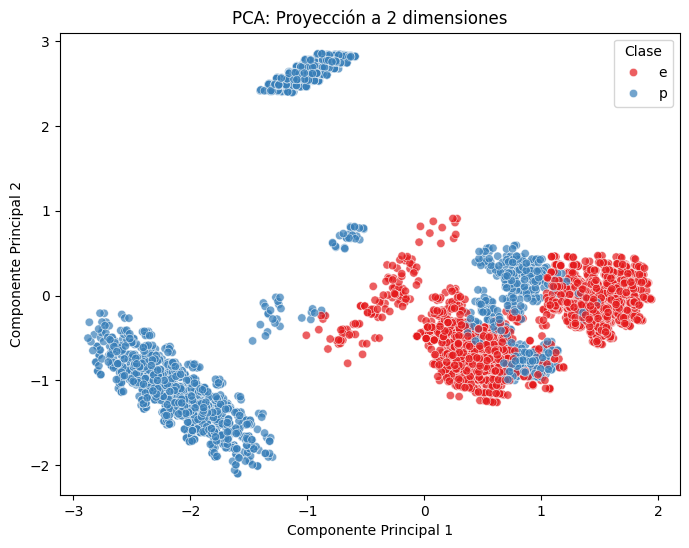

In [15]:
# Aplicar PCA y transformar los datos de entrenamiento
pca = PCA(n_components=2)   
X_train_pca = pca.fit_transform(X_train)

# Crear un DataFrame con los dos componentes principales
df_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = y_train.values  # Añadir la clase para el color

# Representar en scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='Set1', alpha=0.7)
plt.title("PCA: Proyección a 2 dimensiones")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title='Clase')
plt.show()

Parece que está bastante separadito, parece que a ojo mucho se puede ver :)

Igualmente, vamos a entrenar un clasificador a ver qué tal lo hace antes de editar más

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# 1. Definir el clasificador y el número de estimadores
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenar en train
clf.fit(X_train, y_train)

# 3. Calcular la precisión sobre test
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Precisión del modelo Random Forest: {accuracy:.4f}")

Precisión del modelo Random Forest: 1.0000


Es un conjunto sencillo y Random Forest es muy bueno en su trabajo, Igualmente, vamos a ver qué tamaño tenemos de dataset:


In [17]:
X_train.shape

(5443, 116)

¿Muchas features no? Vamos a reducir las usando PCA.

n_componentes (PCA) 1 precisión: 0.8874
n_componentes (PCA) 2 precisión: 0.9605
n_componentes (PCA) 3 precisión: 0.9892
n_componentes (PCA) 4 precisión: 0.9940
n_componentes (PCA) 5 precisión: 0.9989
n_componentes (PCA) 6 precisión: 0.9996
n_componentes (PCA) 7 precisión: 0.9996
n_componentes (PCA) 8 precisión: 1.0000
n_componentes (PCA) 9 precisión: 0.9996
n_componentes (PCA) 10 precisión: 0.9996
n_componentes (PCA) 11 precisión: 1.0000
n_componentes (PCA) 12 precisión: 1.0000
n_componentes (PCA) 13 precisión: 1.0000
n_componentes (PCA) 14 precisión: 1.0000
n_componentes (PCA) 15 precisión: 1.0000


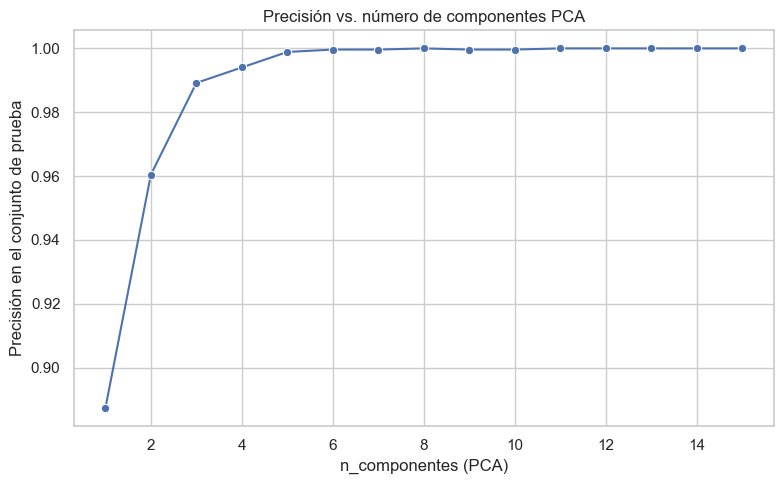

In [18]:
n_features = range(1, X_train.shape[1] - 100)
scores = []

for n in n_features:
    # 1. PCA
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # 2. Random Forest
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train_pca, y_train)

    # 3. Evaluación del rendimiento
    y_pred = clf.predict(X_test_pca)
    score = accuracy_score(y_test, y_pred)
    print(f"n_componentes (PCA) {n} precisión: {score:.4f}")
    scores.append(score)

# Visualización
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(n_features), y=scores, marker='o')
plt.xlabel("n_componentes (PCA)")
plt.ylabel("Precisión en el conjunto de prueba")
plt.title("Precisión vs. número de componentes PCA")
plt.tight_layout()
plt.show()

Vale, estamos viendo que a partir de unas 10 features ya tenemos el score que queríamos y además hemos reducido las variables a un 10% de las que teníamos, incluso menos que las variables originales.

Eficiencia del PCA tras la Selección de Características:

Para explicar el 80% de la varianza se necesitan: 20 componentes
Para explicar el 90% de la varianza se necesitan: 31 componentes
Para explicar el 95% de la varianza se necesitan: 40 componentes
Número total de características: 116


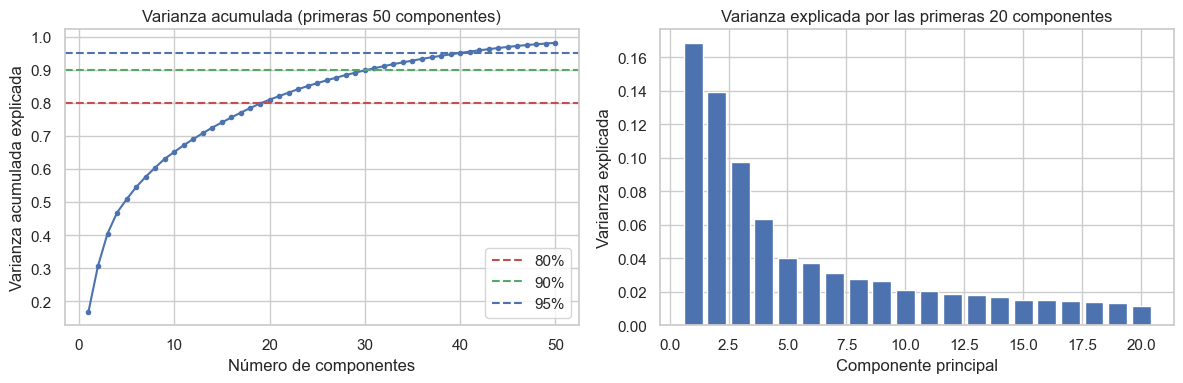

Se seleccionaron 50 características de un total de 116

Antes de la selección de características:
8 componentes explican: 60.4%

Después de la selección de características:
8 componentes explican: 70.7%


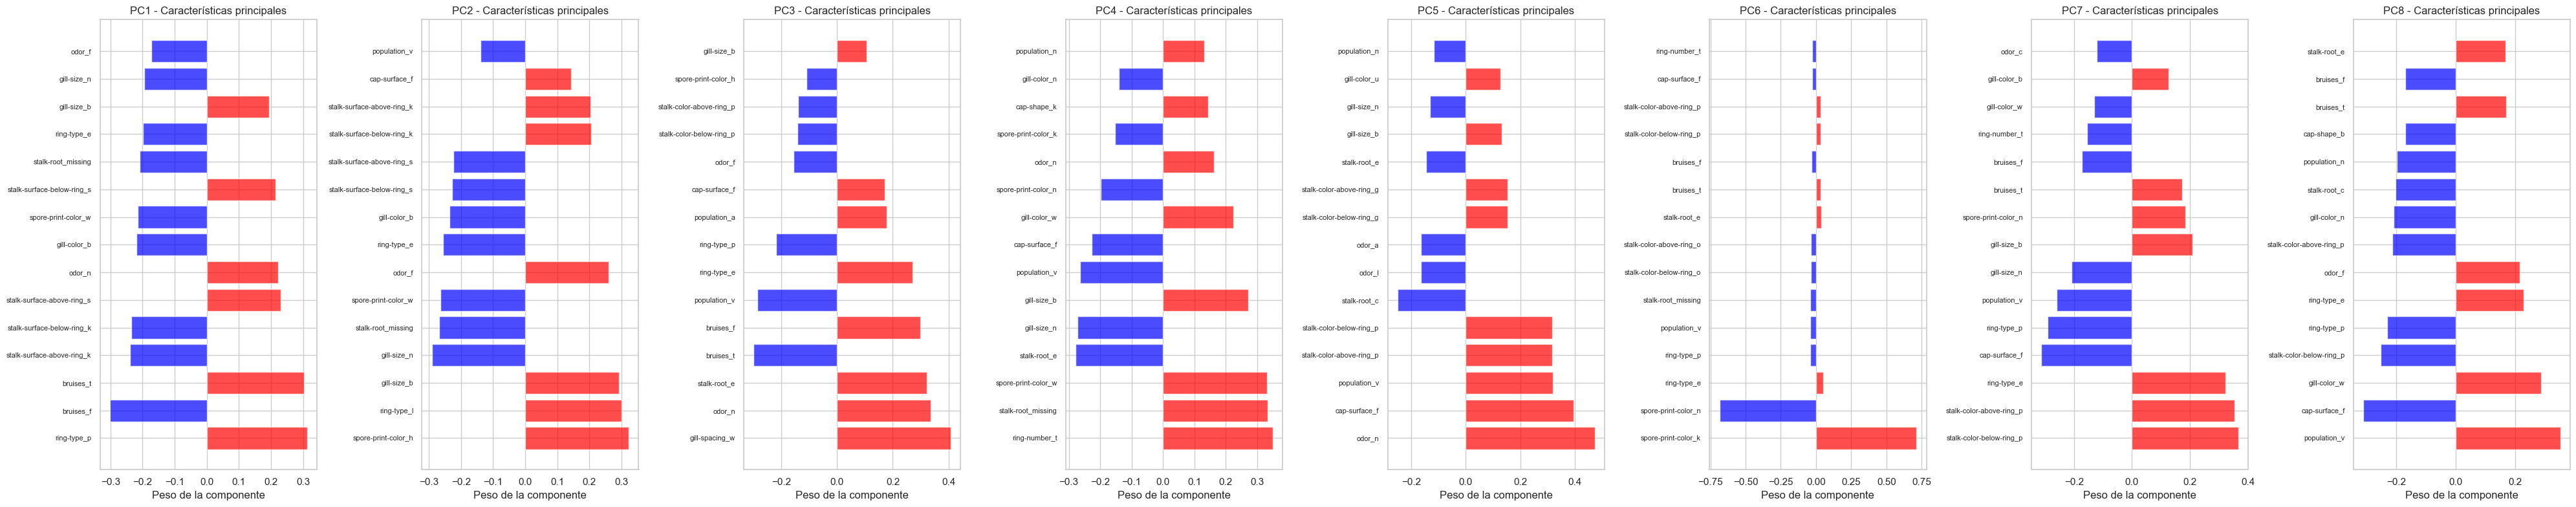

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
cap-shape_b,0.031703,-0.003848,-0.010995,0.124113,-0.118063,-0.011023,-0.049348,-0.171201
cap-shape_k,-0.073319,-0.095376,0.003232,0.145053,0.031238,-0.014267,-0.045772,-0.034017
cap-surface_f,0.056570,0.143560,0.171579,-0.227792,0.395063,-0.029300,-0.312329,-0.312255
bruises_f,-0.301967,0.035660,0.299727,-0.069268,-0.004996,-0.033788,-0.173072,-0.171078
bruises_t,0.301967,-0.035660,-0.299727,0.069268,0.004996,0.033788,0.173072,0.171078
odor_a,0.036762,-0.001121,-0.049680,0.022922,-0.163350,0.003351,0.048834,-0.107463
odor_c,0.004470,-0.011534,0.003473,-0.080436,-0.042150,-0.007879,-0.121714,-0.081247
odor_f,-0.172310,0.260603,-0.156257,-0.027279,-0.018062,0.002951,0.012339,0.216547
odor_l,0.036762,-0.001121,-0.049680,0.022922,-0.163350,0.003351,0.048834,-0.107463
odor_n,0.221860,-0.055621,0.335222,0.162209,0.472619,-0.024927,-0.031055,0.127413


In [ ]:
# Análisis PCA mejorado para el dataset de setas
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, chi2


# 1. ANÁLISIS DE VARIANZA TOTAL CON PCA
def analyze_full_pca_variance(X_encoded):
    """Análisis de la varianza total explicada por PCA"""
    pca_full = PCA()
    pca_full.fit(X_encoded)

    cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

    # Determinar cuántos componentes se necesitan para explicar el 80%, 90% y 95% de la varianza
    n_80 = np.argmax(cumsum_variance >= 0.80) + 1
    n_90 = np.argmax(cumsum_variance >= 0.90) + 1
    n_95 = np.argmax(cumsum_variance >= 0.95) + 1

    print(f"Para explicar el 80% de la varianza se necesitan: {n_80} componentes")
    print(f"Para explicar el 90% de la varianza se necesitan: {n_90} componentes")
    print(f"Para explicar el 95% de la varianza se necesitan: {n_95} componentes")
    print(f"Número total de características: {X_encoded.shape[1]}")

    # Visualización
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, min(51, len(cumsum_variance) + 1)),
             cumsum_variance[:50], marker='o', markersize=3)
    plt.axhline(y=0.80, color='r', linestyle='--', label='80%')
    plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
    plt.axhline(y=0.95, color='b', linestyle='--', label='95%')
    plt.xlabel('Número de componentes')
    plt.ylabel('Varianza acumulada explicada')
    plt.title('Varianza acumulada (primeras 50 componentes)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.bar(range(1, 21), pca_full.explained_variance_ratio_[:20])
    plt.xlabel('Componente principal')
    plt.ylabel('Varianza explicada')
    plt.title('Varianza explicada por las primeras 20 componentes')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return pca_full

# 2. SELECCIÓN PREVIA DE CARACTERÍSTICAS
def feature_selection_before_pca(X_encoded, y, k=50):
    """Seleccionar las características más informativas antes de aplicar PCA"""
    # Prueba chi-cuadrado para datos categóricos
    selector = SelectKBest(score_func=chi2, k=k)
    X_selected = selector.fit_transform(X_encoded, y)

    selected_features = X_encoded.columns[selector.get_support()]
    print(f"Se seleccionaron {len(selected_features)} características de un total de {X_encoded.shape[1]}")

    # Comparar PCA antes y después de la selección
    pca_before = PCA(n_components=8)
    pca_after = PCA(n_components=8)

    pca_before.fit(X_encoded)
    pca_after.fit(X_selected)

    print(f"\nAntes de la selección de características:")
    print(f"8 componentes explican: {sum(pca_before.explained_variance_ratio_):.1%}")

    print(f"\nDespués de la selección de características:")
    print(f"8 componentes explican: {sum(pca_after.explained_variance_ratio_):.1%}")

    return X_selected, selected_features, pca_after

# 3. INTERPRETACIÓN DE COMPONENTES PCA
def interpret_pca_components(pca, feature_names, n_components=8):
    """Interpretación de los componentes principales"""
    components_df = pd.DataFrame(
        pca.components_[:n_components].T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=feature_names
    )

    # Visualización de los pesos de cada característica en las componentes
    fig, axes = plt.subplots(1, n_components, figsize=(5*n_components, 8))
    if n_components == 1:
        axes = [axes]

    for i in range(n_components):
        pc_series = components_df[f'PC{i+1}'].abs().sort_values(ascending=False)
        top_features = pc_series.head(15)

        colors = ['red' if components_df.loc[feat, f'PC{i+1}'] > 0 else 'blue'
                 for feat in top_features.index]

        axes[i].barh(range(len(top_features)),
                    [components_df.loc[feat, f'PC{i+1}'] for feat in top_features.index],
                    color=colors, alpha=0.7)
        axes[i].set_yticks(range(len(top_features)))
        axes[i].set_yticklabels([feat.split('_')[0] + '_' + feat.split('_')[1]
                               if len(feat.split('_')) > 1 else feat
                               for feat in top_features.index], fontsize=8)
        axes[i].set_title(f'PC{i+1} - Características principales')
        axes[i].set_xlabel('Peso de la componente')

    plt.tight_layout()
    plt.show()

    return components_df

# 1. Análisis completo de PCA
pca_full = analyze_full_pca_variance(X_encoded)

# 2. Selección de características y nuevo PCA
X_selected, selected_features, pca_improved = feature_selection_before_pca(X_encoded, y, k=50)

# 3. Interpretación de los componentes principales
interpret_pca_components(pca_improved, selected_features, n_components=8)

# Conclusiones del Análisis PCA Mejorado

## Mejora en la Eficiencia del PCA tras la Selección de Características

Los resultados muestran una **mejora significativa** en la eficiencia del PCA después de aplicar selección de características:

### Antes de la selección de características:
- 8 componentes principales explicaban el **60.4%** de la varianza total
- Se trabajaba con las 116 características originales

### Después de la selección de características:
- 8 componentes principales explican el **70.7%** de la varianza total
- Se redujo a 50 características más informativas (seleccionadas mediante chi-cuadrado)

## Interpretación de la Mejora

La **ganancia del 10.3%** (de 60.4% a 70.7%) en varianza explicada representa:

1. **Mayor concentración de información**: Al eliminar características menos informativas, los componentes principales pueden capturar mejor la estructura subyacente de los datos

2. **Reducción del ruido**: La selección previa de características eliminó variables que principalmente añadían ruido, permitiendo que el PCA se enfoque en las relaciones más importantes

3. **Eficiencia mejorada**: Con menos dimensiones pero mayor poder explicativo, el modelo es más eficiente y potencialmente más generalizable



## Clustering

Viendo que el conjunto de datos es sencillito, podemos intentar hacer algo de clustering a ver qué información podemos obtener.

El primer paso va a ser importar la función de Kmeans de sklearn, y a partir de ahi, vamos a buscar el valor óptimo de clusters. Como hemos visto anteriormente, este valor lo obtenemos, por ejemplo, del codo de la gráfica que representa el total de las distancias de los puntos a los centros de los clusters asociados. Os dejo la página de la documentación de sklearn para que lo busquéis:

[K-Means on sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

Con esto solo hay que ahora generar los modelos de kmeans, evaluar y pintar la gráfica para los valores de ``k`` que establezcais.




Número óptimo de clústeres: 10


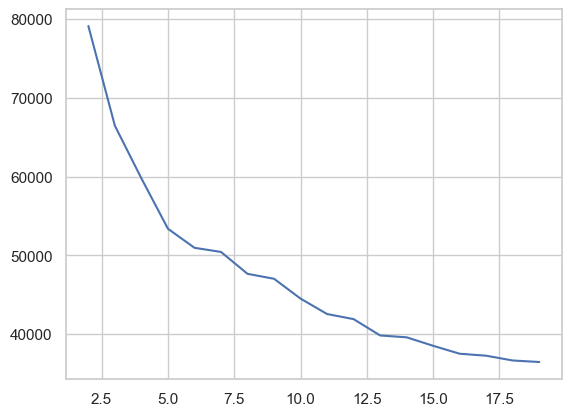

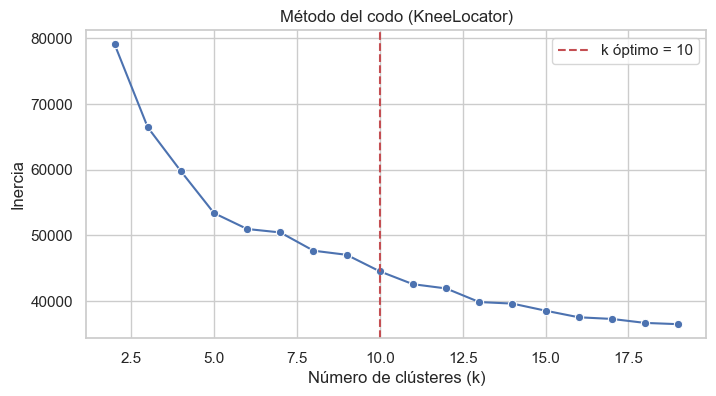

In [20]:
from kneed import KneeLocator
import matplotlib.pyplot as plt
import seaborn as sns
scores = []
k_values = range(2,20)
for a in k_values:
    kmeans = KMeans(n_clusters=a, random_state=0).fit(X_encoded)
    scores.append(kmeans.inertia_)

sns.lineplot(x=k_values, y=scores)
# 2. Búsqueda automática del "codo"
knee = KneeLocator(k_values, scores, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print(f"Número óptimo de clústeres: {optimal_k}")

# 3. Visualización
plt.figure(figsize=(8, 4))
sns.lineplot(x=k_values, y=scores, marker='o')
plt.axvline(optimal_k, color='r', linestyle='--', label=f"k óptimo = {optimal_k}")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")
plt.title("Método del codo (KneeLocator)")
plt.legend()
plt.grid(True)
plt.show()

Eligiendo el numero de clasters con Bayesian information criterion (BIC) y the Akaike information criterion
 (AIC):

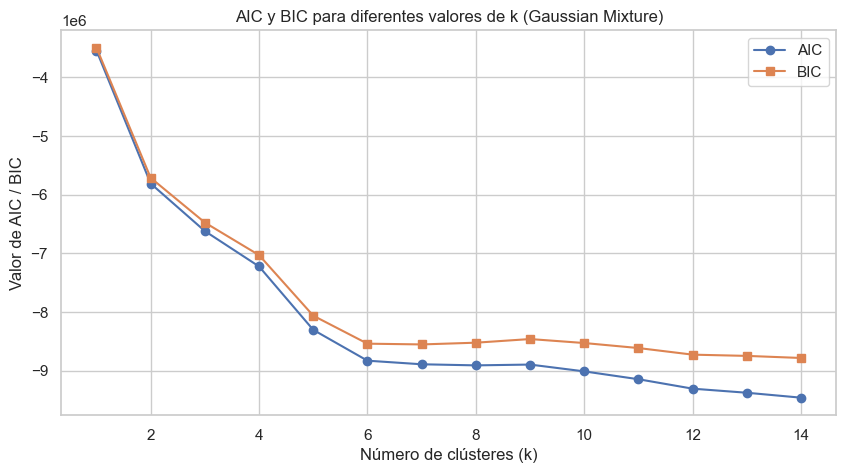

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

n_components = range(1, 15)  # Número de clústeres (k)
aic = []
bic = []

for k in n_components:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_encoded)
    aic.append(gmm.aic(X_encoded))
    bic.append(gmm.bic(X_encoded))

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(n_components, aic, label='AIC', marker='o')
plt.plot(n_components, bic, label='BIC', marker='s')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Valor de AIC / BIC')
plt.title('AIC y BIC para diferentes valores de k (Gaussian Mixture)')
plt.legend()
plt.grid(True)
plt.show()


Ambos métodos de clustering convergen en la misma solución, identificando 10 clústeres

Con el valor que hayáis obtenido de la gráfica, podéis obtener una buena aproximación de Kmeans y con ello podemos pasar a explorar cómo de bien han separado la información los distintos clusters. Para ello, se va a hacer un ``catplot``, seaborn os lo hará solito. Con esto lo que se pretende ver es la distribución de la varaible a predecir en función del cluster que haya determinado Kmeans.

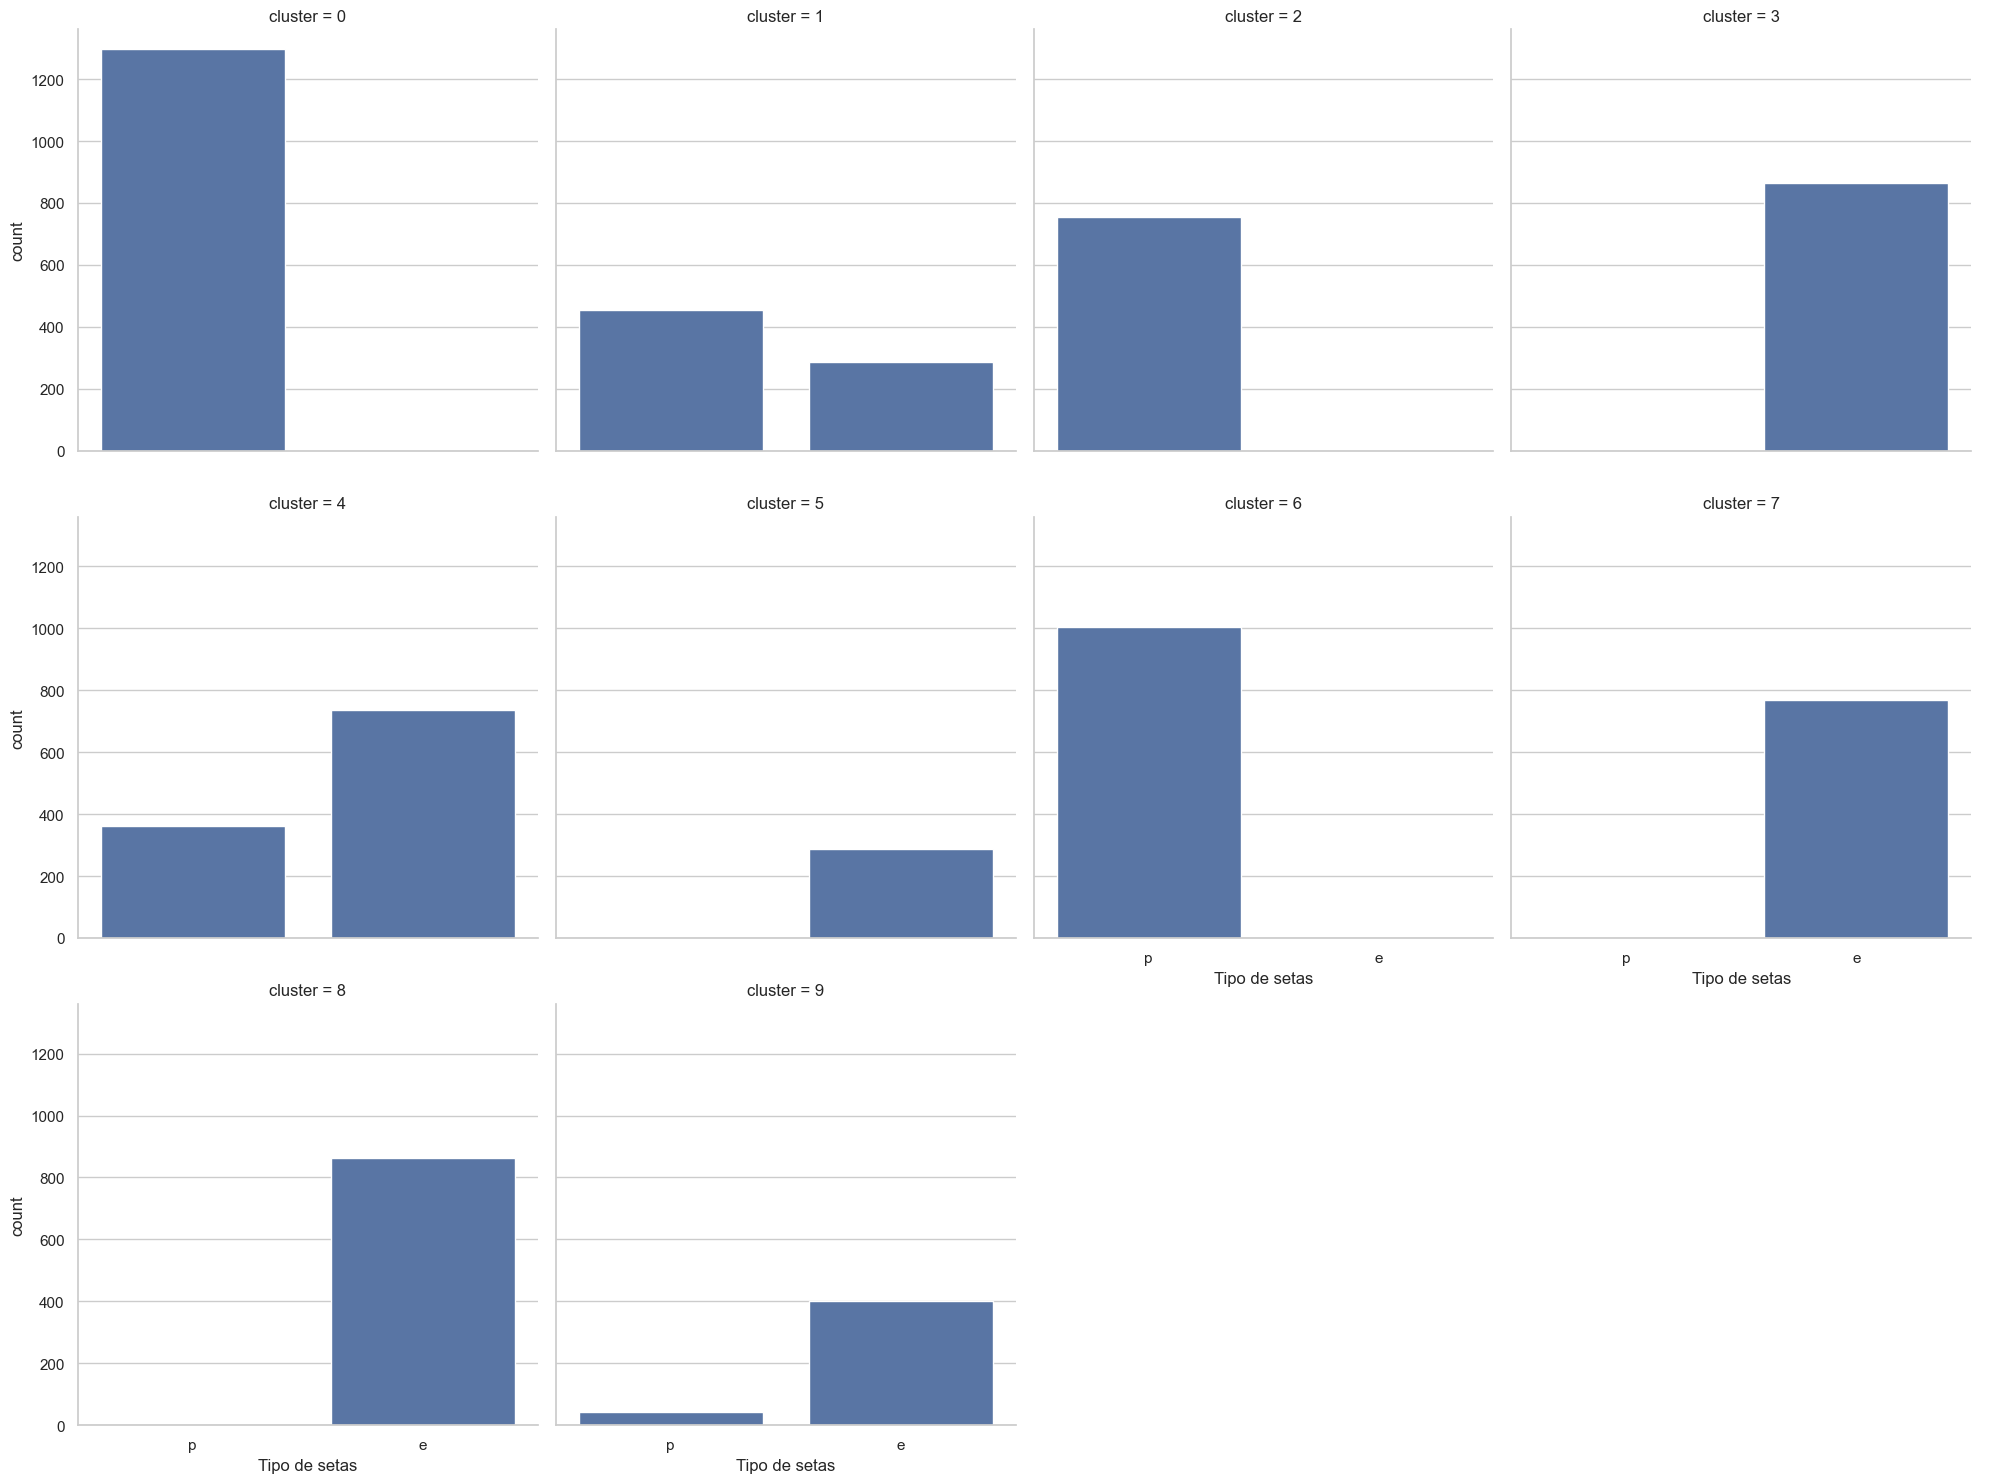

In [22]:
#Aprender Kmeans con el valor de K obtenido.
kmeans = KMeans(n_clusters=10, random_state=0).fit(X_encoded)

# Preparar el catplot.
cluster_result = pd.DataFrame()
cluster_result['cluster'] = kmeans.predict(X_encoded)
cluster_result['Tipo de setas'] = y

ax = sns.catplot(col='cluster', x='Tipo de setas', data=cluster_result, kind='count',col_wrap=4)

Vamos a ver qué tal queda esto pintado. Para ello, repetimos el scatterplot de antes pero usando como color el cluster asignado por kmeans.

<Axes: >

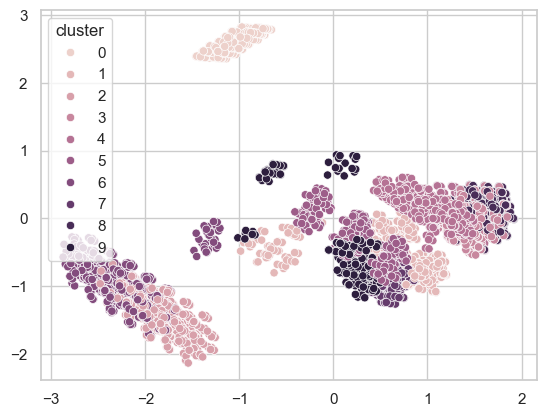

In [23]:
# Entrenar PCA para representar.
# Usar un color por cada cluster.
pca = PCA(n_components=2)
pca.fit(X_encoded)
viz = pca.transform(X_encoded)

sns.scatterplot(x = viz[:,0], y = viz[:,1],  hue = cluster_result['cluster'], legend = "full")

¿Es bastante parecido no? No es tan bueno como el Random Forest, pero ha conseguido identificar bastante bien los distintos puntos del dataset sin utilizar las etiquetas. De hecho, el diagrama de factor que hemos visto antes muestra que solo un par de clusters son imprecisos. Si no hubieramos tenido etiquetas esta aproximacion nos hubiera ayudado mucho a clasificar los distintos tipos de hongos.